# MDS
20260105 ~ 

### mean:
    - ✅t=10^x (x: integer, -3~8)でMDS
### individual:
    1. 何人かピックアップ
        1.1 正定値1名
        1.2 gapあり3名（plateauが20以上、10〜20、0~10）
        1.3 gapなし3名（plateauが20以上、10〜20、0~10）
    2. t=10^x (x: integer, -3~8)でMDS
    3. 1.2の場合、gapの直前直後のtをgenmag baseで探し、そこもMDS

### 正定値との関連
- /metrics/positivedefiniteで、Trueになってる人でFalseのところ、Trueのところ、Falseの人でもみてみる

In [1]:
import os
import sys
import numpy as np
import pandas as pd
from sklearn.manifold import MDS

project_root = os.path.abspath("/home/jovyan/work")
print("Project root:", project_root)

if project_root not in sys.path:
    sys.path.append(project_root)

from funcs import core, viz

Project root: /home/jovyan/work


In [2]:
# load data
h5_path_mean = project_root + "/data/processed/amy_processeddata_mean.h5"

with pd.HDFStore(h5_path_mean, mode="r") as store:
    dissim_mean_df = store["dissim/mean"]
dissim_arr = dissim_mean_df.to_numpy()

In [3]:
# set parameters
n_stim = len(dissim_mean_df)
t_power = np.arange(-3, 9)
figpath = os.path.join(project_root, "fig/MDS/mean")

In [4]:
# initialization
dissim_scaled = np.stack(
    [dissim_arr * np.float_power(10, t) for t in t_power],
    axis=0
)

mds_res_mean_dim2 = np.zeros((len(t_power), n_stim, 2))
mds_res_mean_dim3 = np.zeros((len(t_power), n_stim, 3))

# calculate MDS
for i in range(len(t_power)):
    mds_mean_2 = MDS(n_components=2, dissimilarity="precomputed", random_state=0, normalized_stress="auto")
    mds_mean_3 = MDS(n_components=3, dissimilarity="precomputed", random_state=0, normalized_stress="auto")

    mds_res_mean_dim2[i] = mds_mean_2.fit_transform(dissim_scaled[i])
    mds_res_mean_dim3[i] = mds_mean_3.fit_transform(dissim_scaled[i])

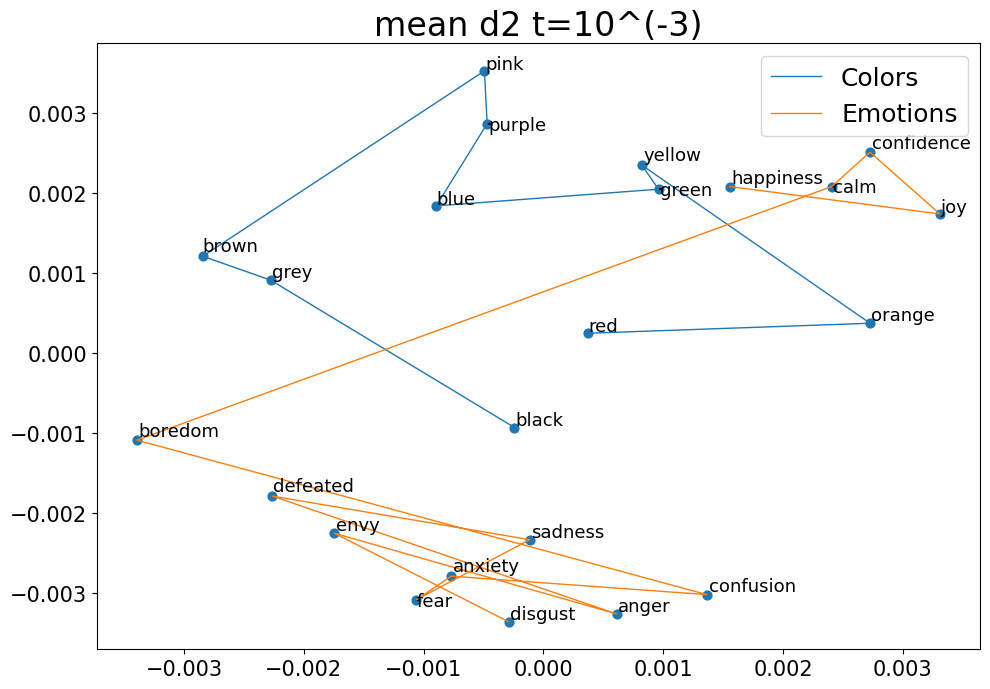

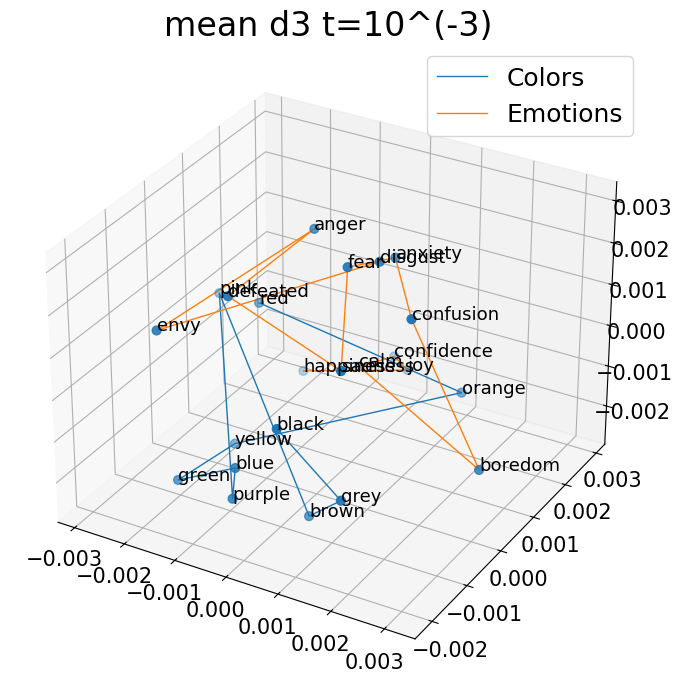

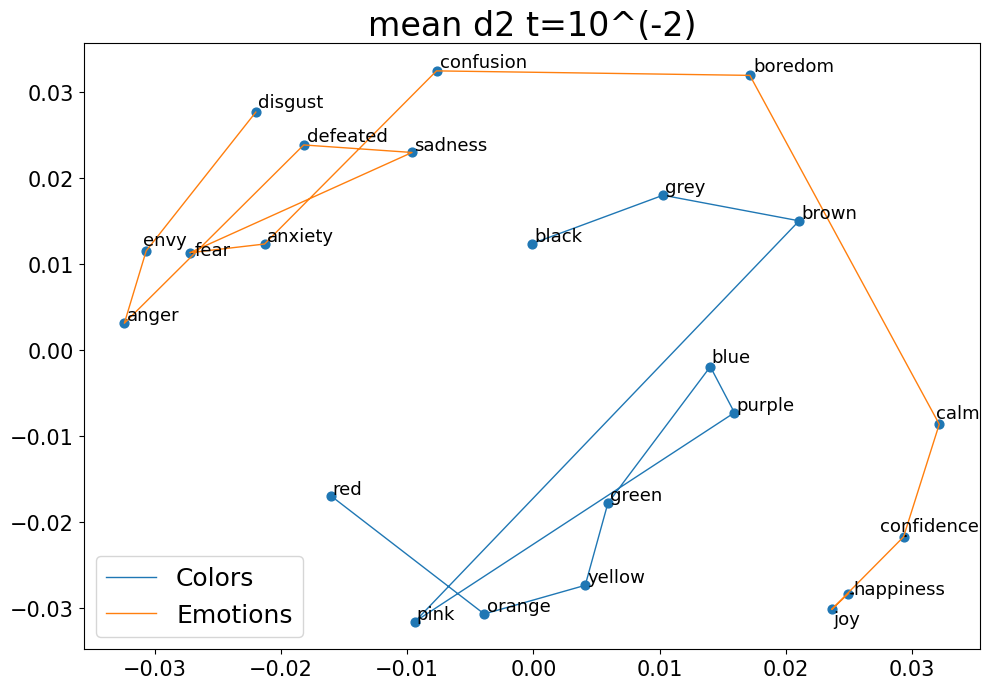

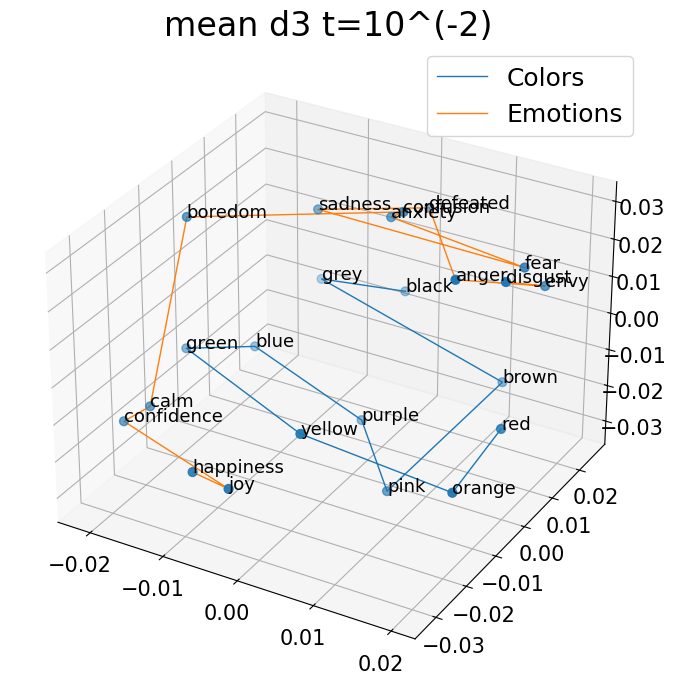

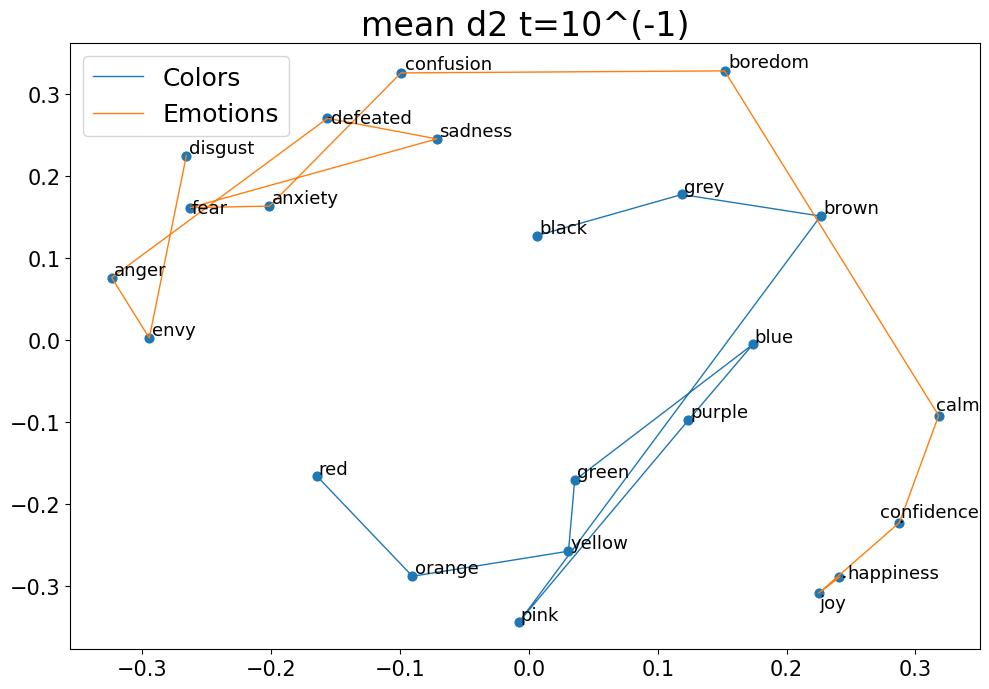

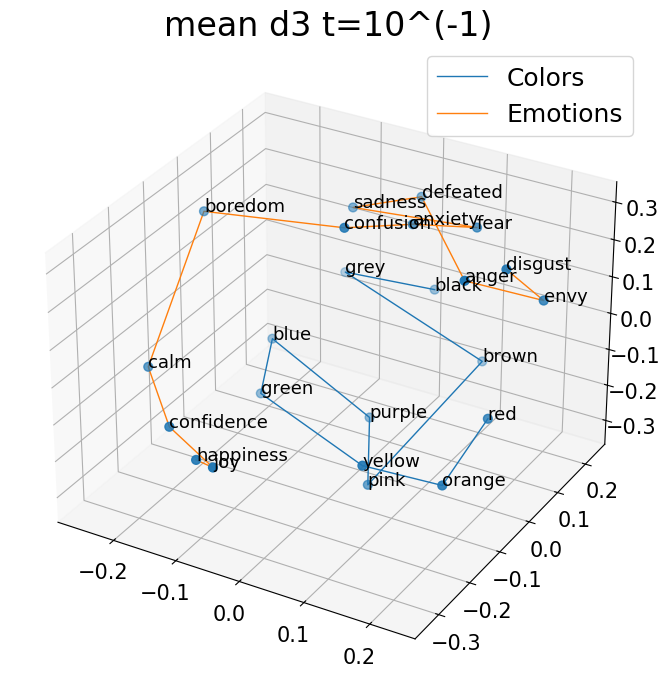

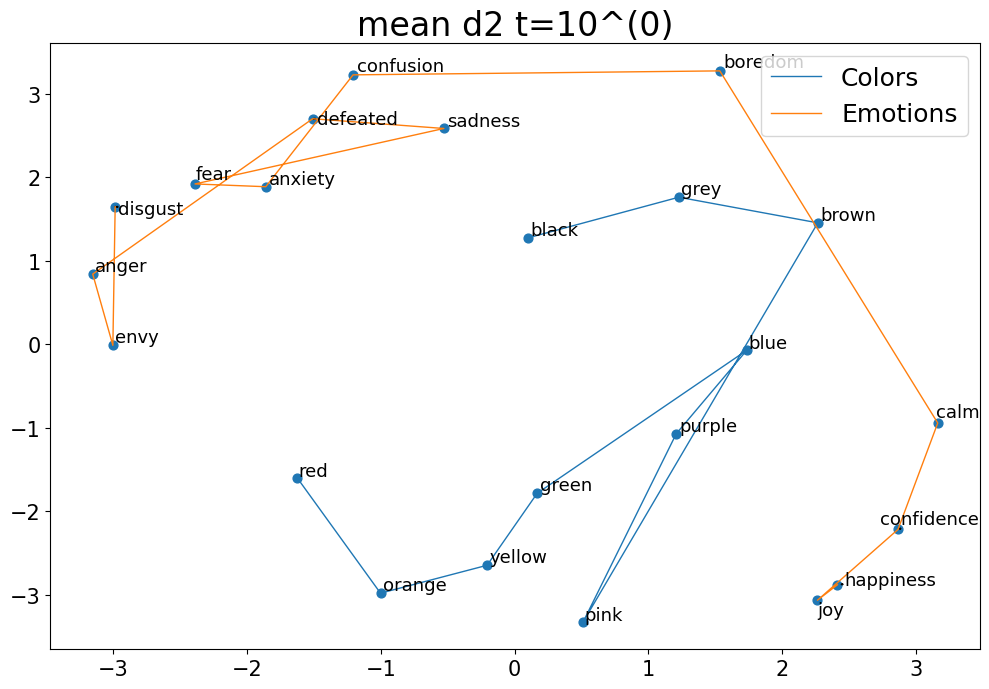

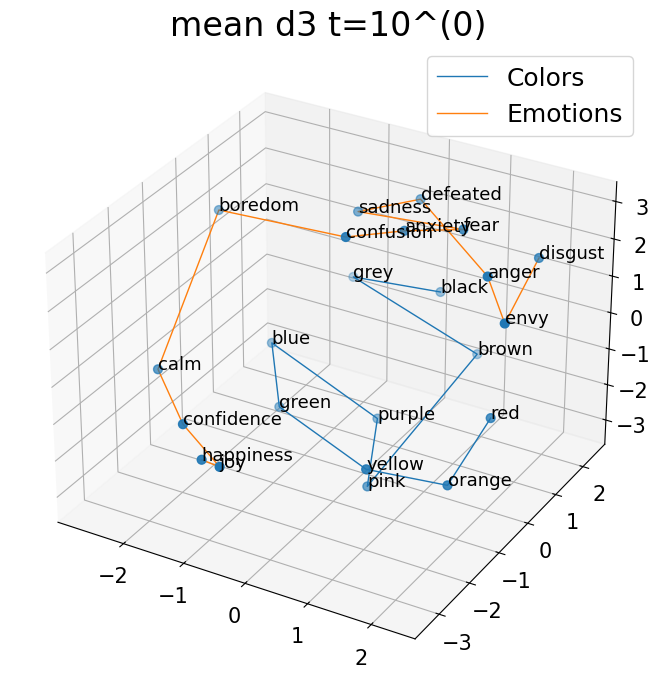

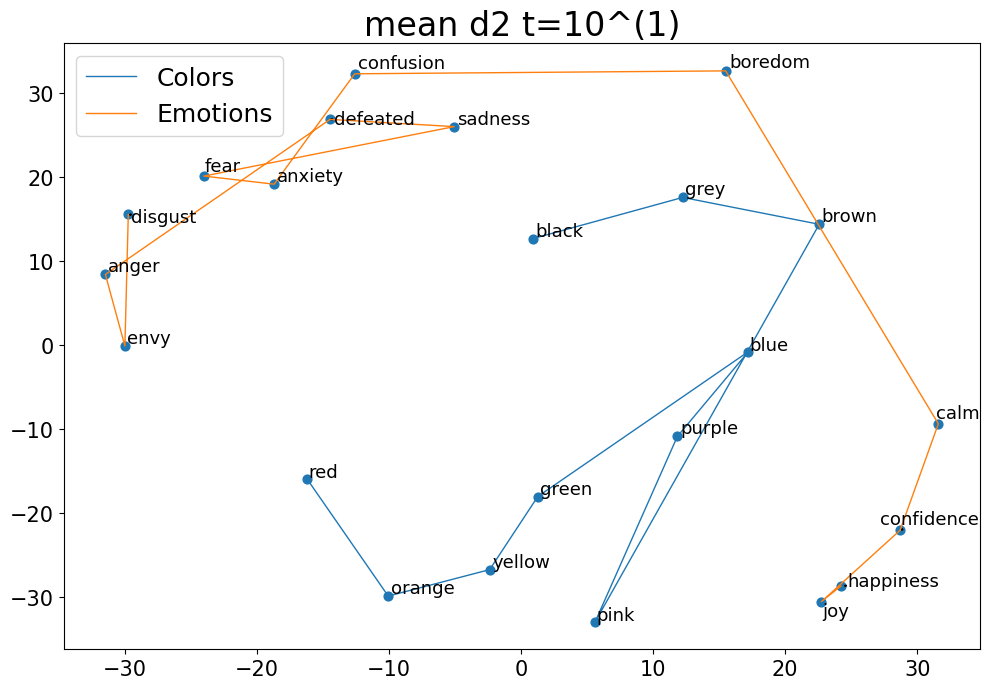

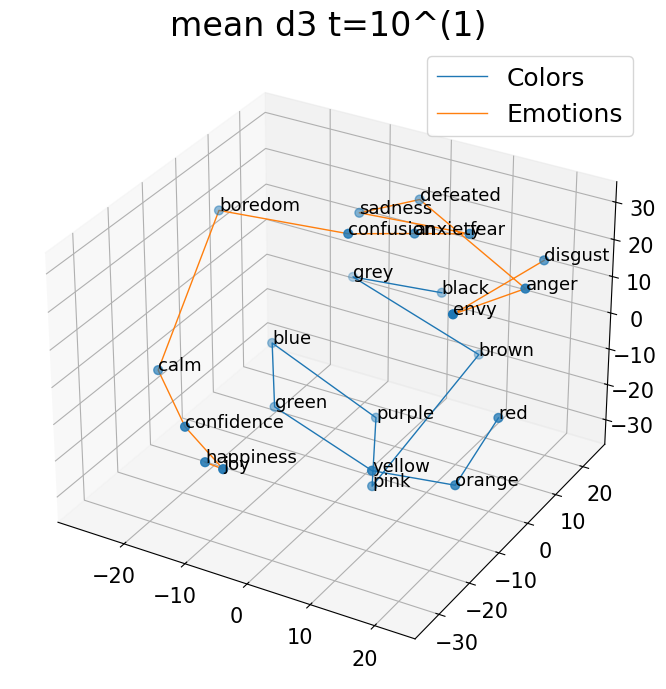

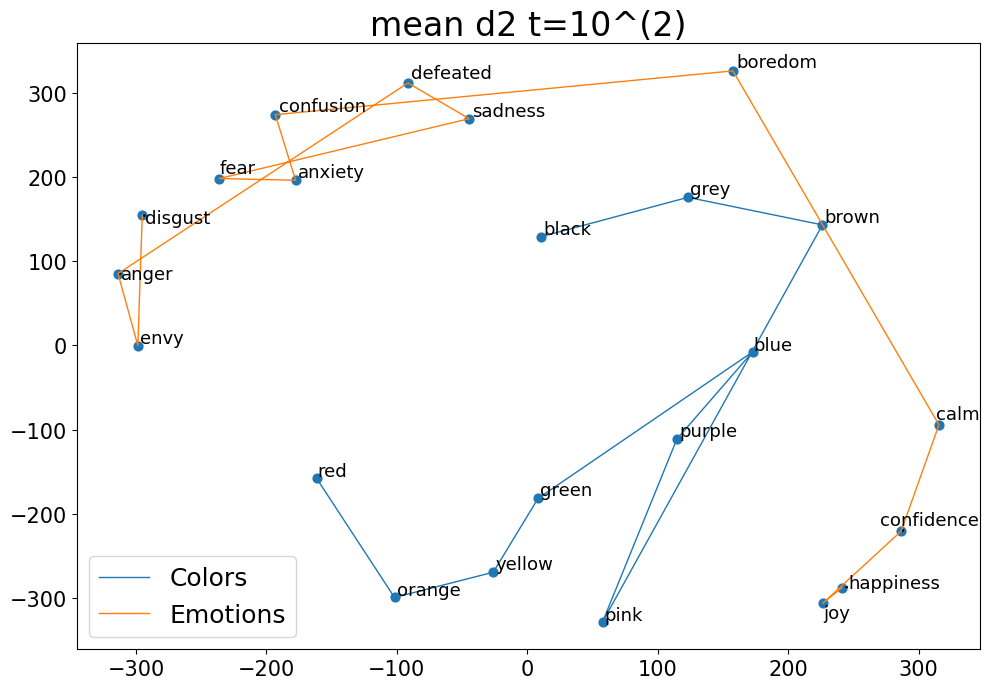

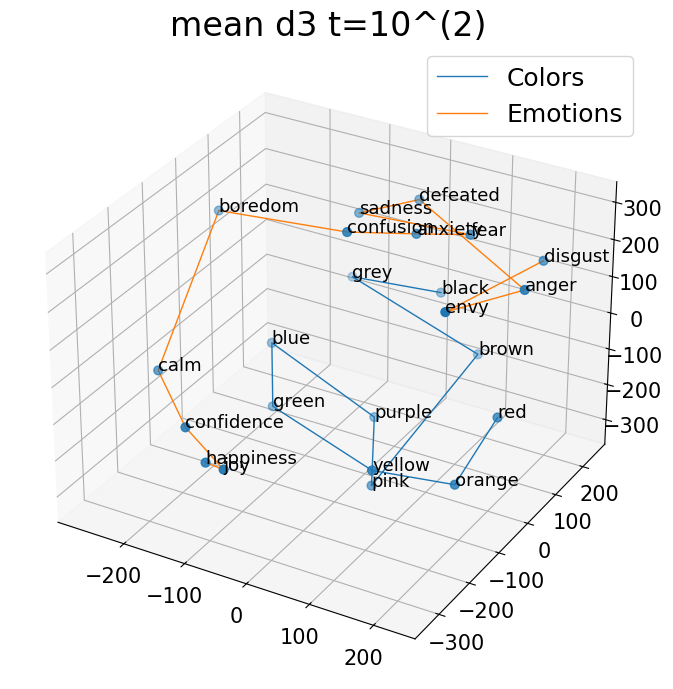

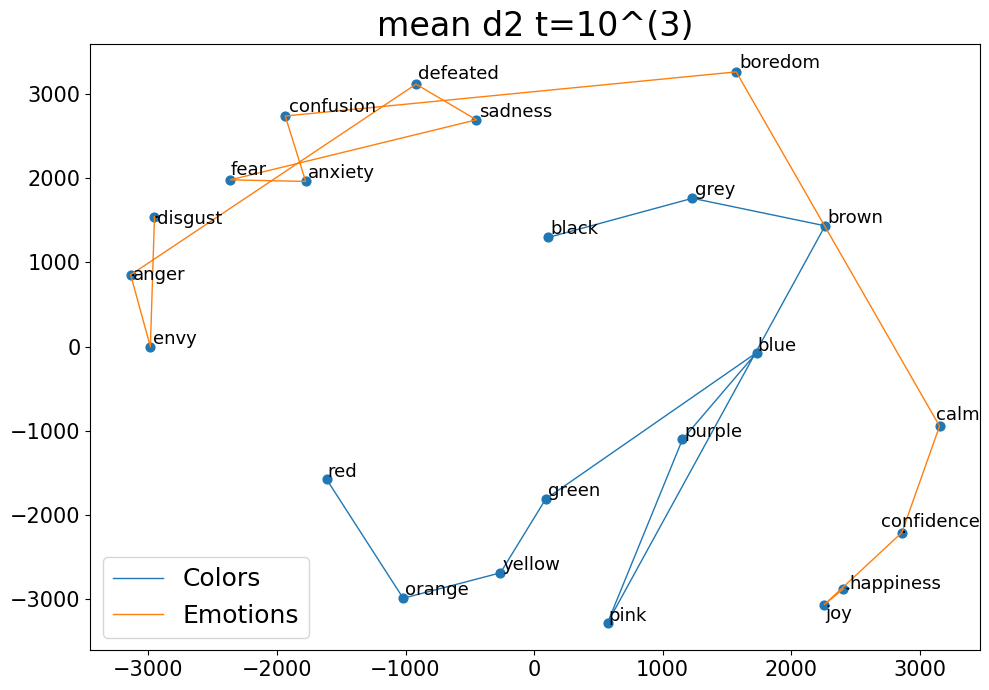

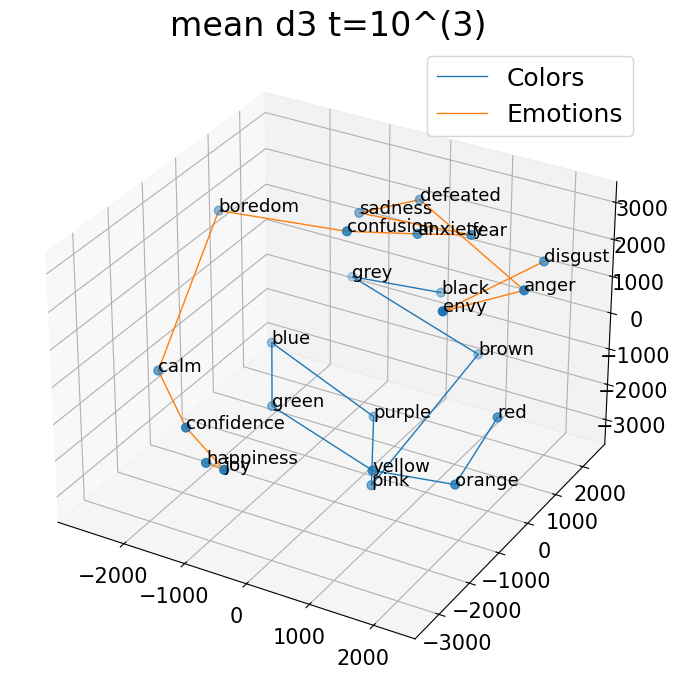

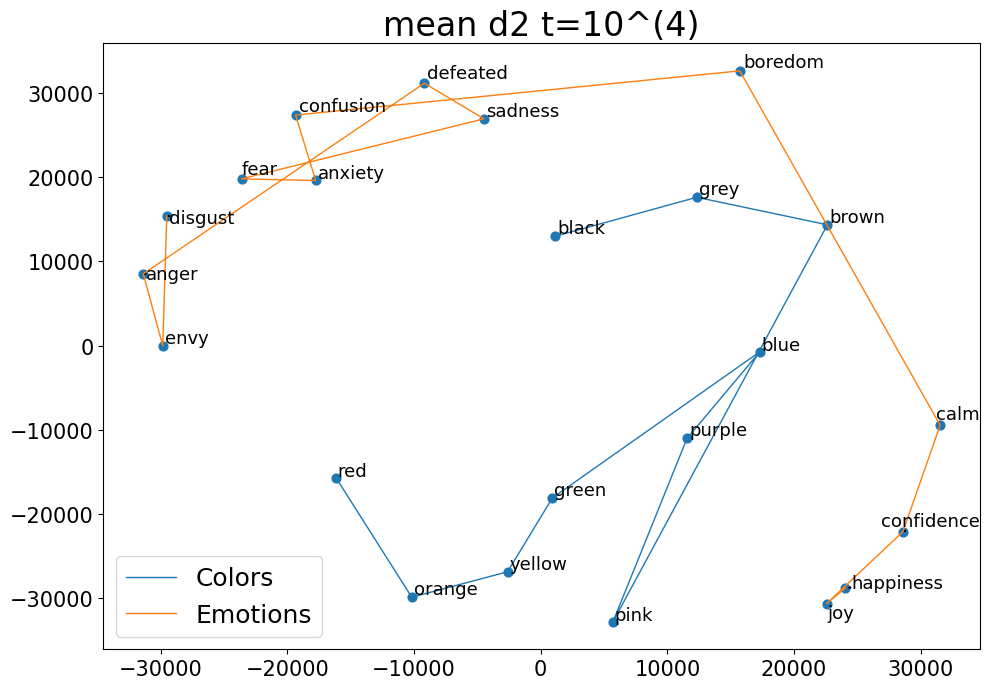

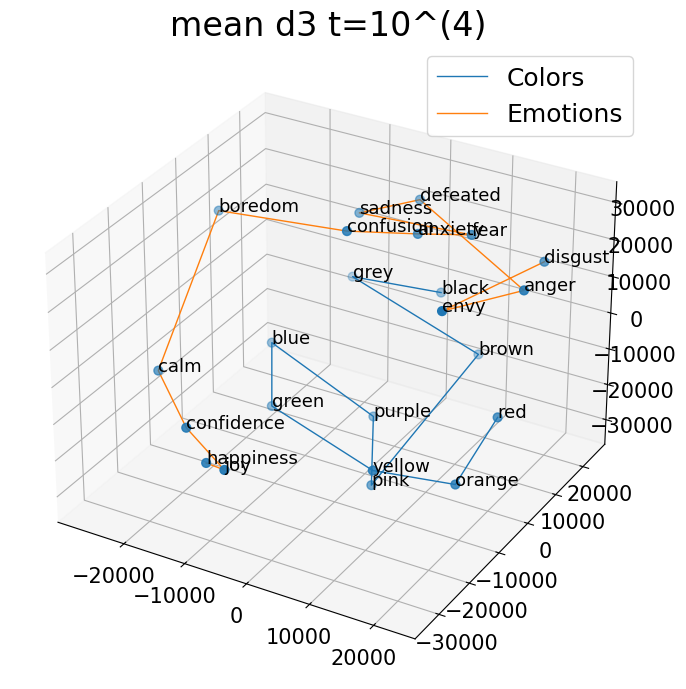

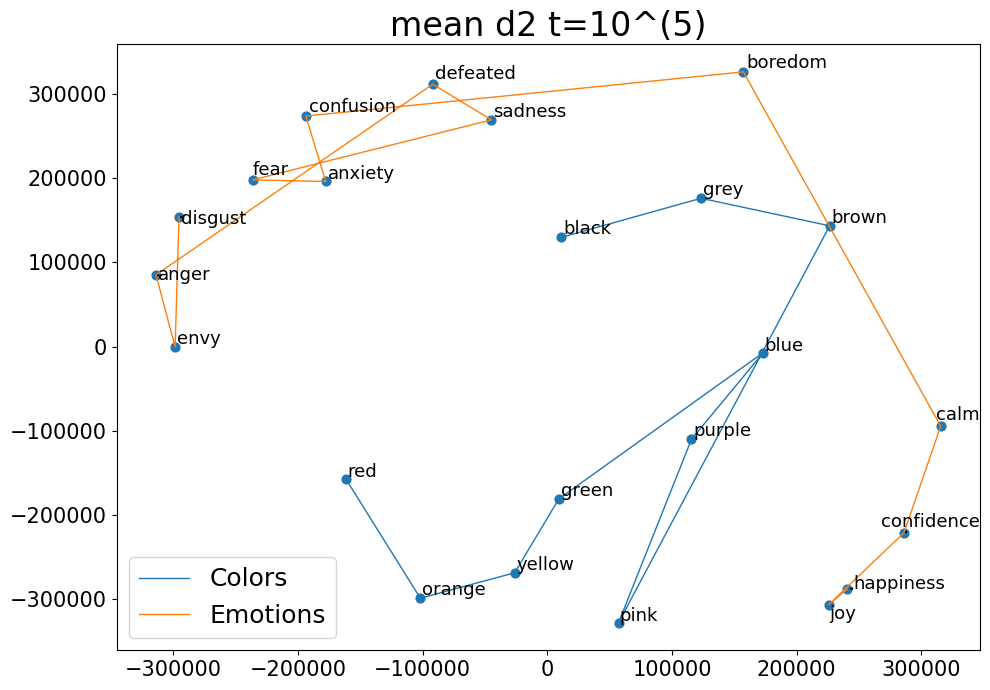

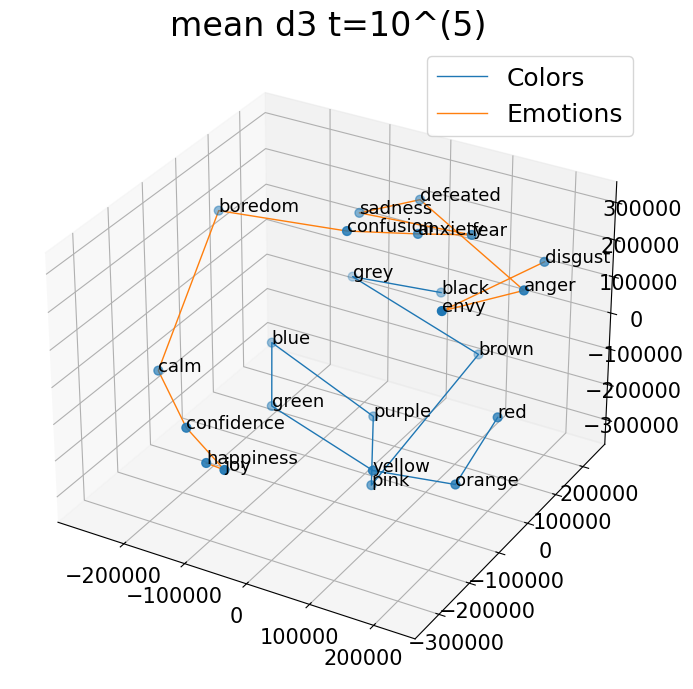

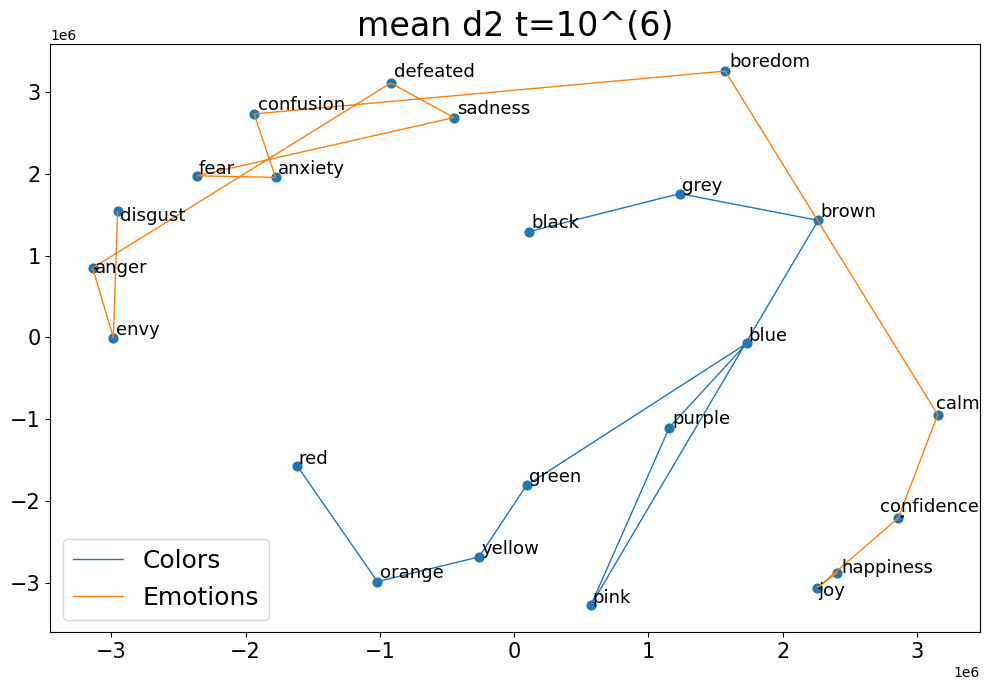

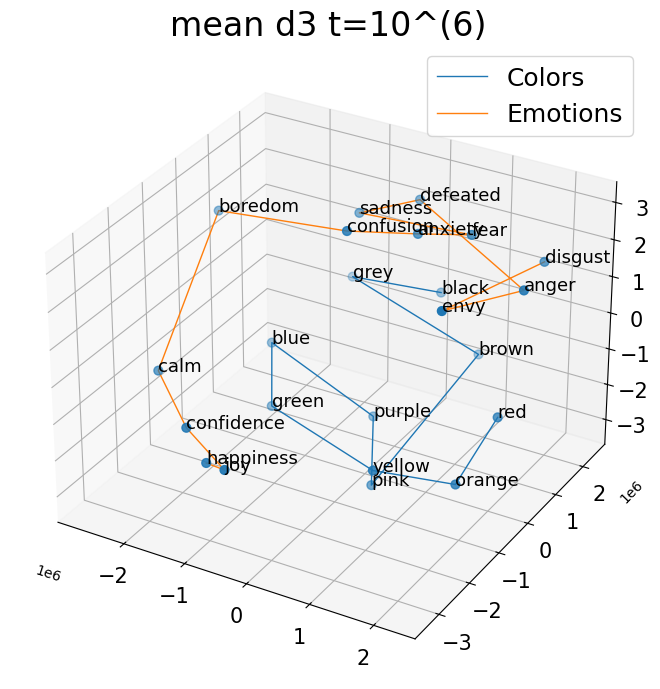

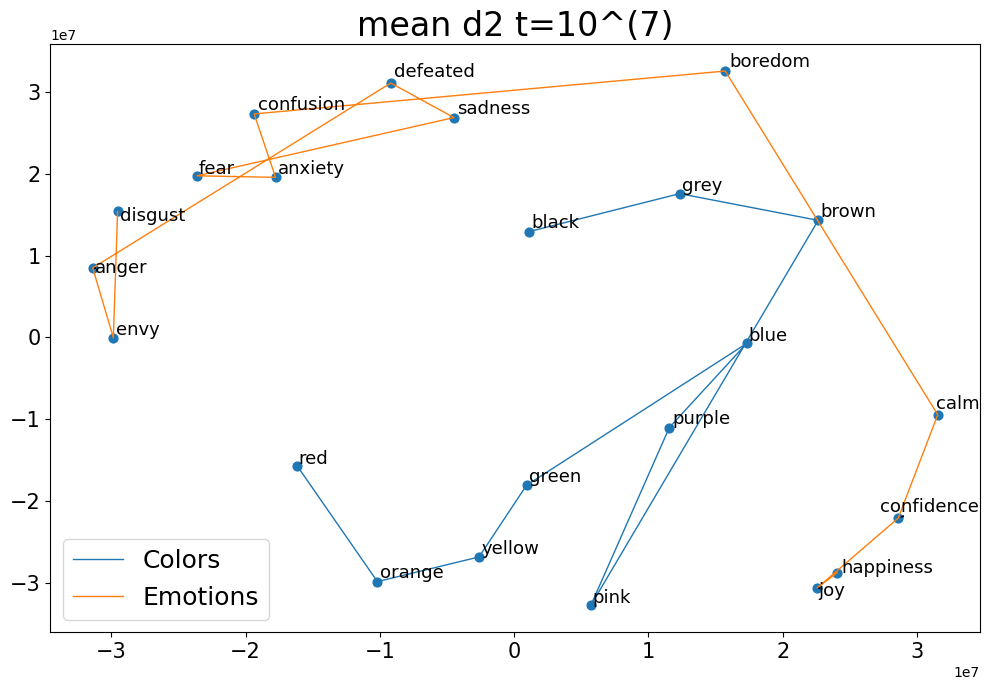

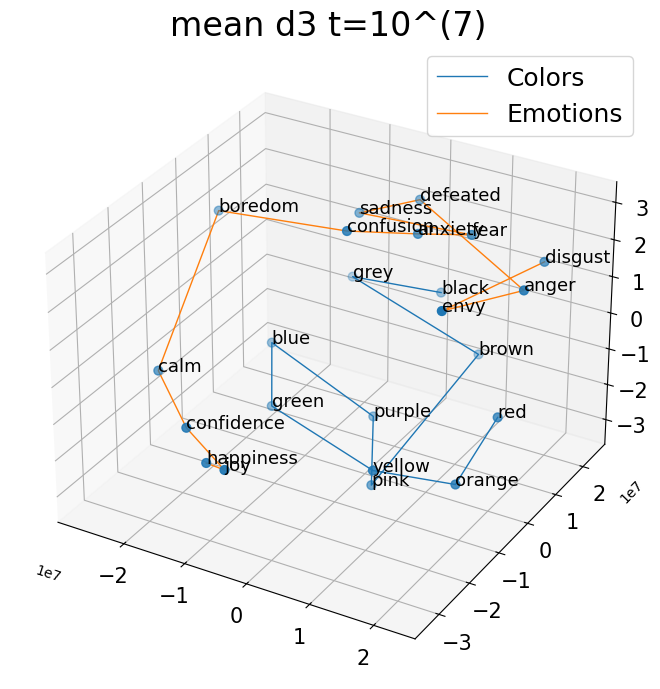

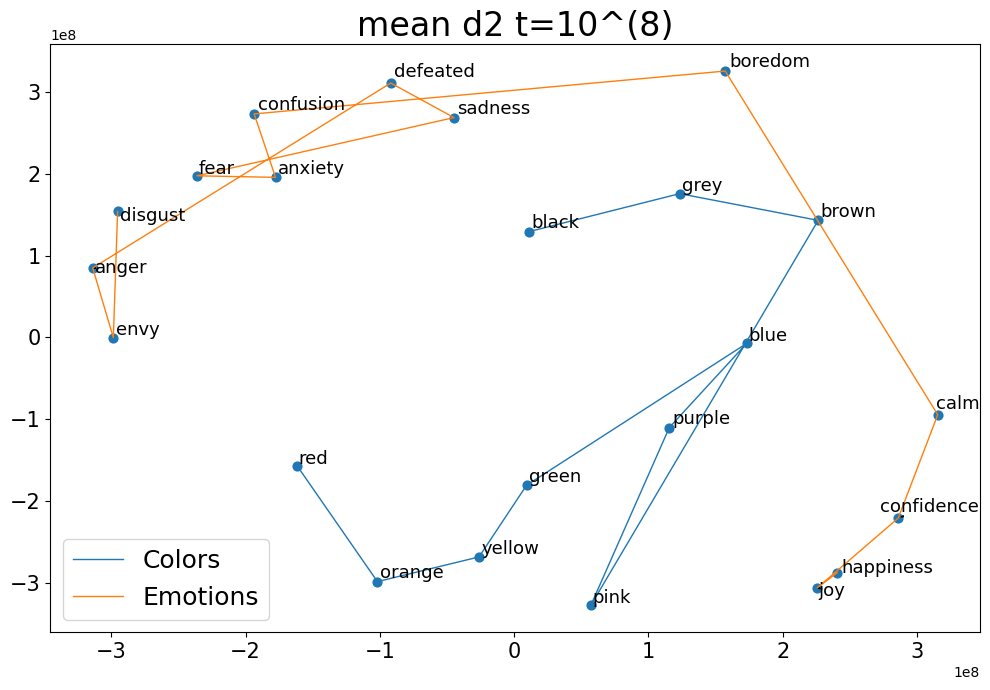

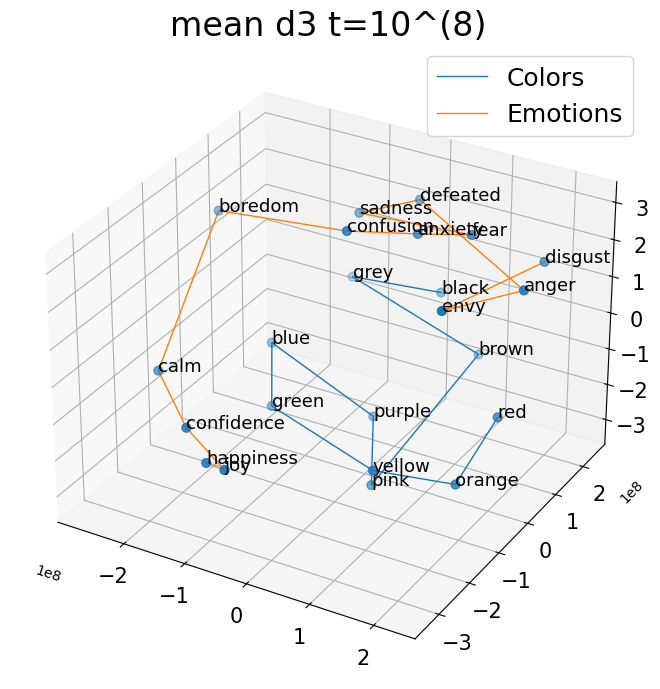

In [6]:
# visualization
for i, t in enumerate(t_power):
    viz.plt_mds(mds_res_mean_dim2[i], dissim_mean_df, save_path=figpath+f"/mean d2 t=10^({t})")
    viz.plt_mds(mds_res_mean_dim3[i], dissim_mean_df, save_path=figpath+f"/mean d3 t=10^({t})")